# Data Preparation and EDA for TeleNarratives

This notebook loads Telegram channel and message data from Parquet files, performs exploratory data analysis, and prepares stratified samples for strong (manual) and weak (automatic) labeling.

**Data Sources:**
- `data/telegram_channels.parquet` - Channel metadata
- `data/telegram_messages.parquet` - Message data


In [1]:
# Install dependencies if needed
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Install required packages
%pip install -q networkx pandas pyarrow matplotlib seaborn



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, FuncFormatter

# Import helper functions and config
from src.disinfograph.config import get_data_paths
from src.disinfograph.data_cleaner_and_sampler import cleaning_and_preprocessing, stratified_sample_by_week

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


## Step 1: Load & Clean Data from Parquet Files 

**Debug Mode:** Set `LIMIT_RECORDS` to limit the number of messages/channels loaded (useful for testing with smaller datasets).


In [3]:
# LIMIT_RECORDS = 100_000  # Set to a number (e.g., 5000) to limit records for faster loading, or None to load all
LIMIT_RECORDS = None
# Get data paths
paths = get_data_paths(project_root)
print(f"Data paths configured: {paths}")

# Check if files exist
if not paths["channels_parquet"].exists():
    raise FileNotFoundError(f"Channels file not found: {paths['channels_parquet']}")
if not paths["messages_parquet"].exists():
    raise FileNotFoundError(f"Messages file not found: {paths['messages_parquet']}")

print(f"Loading data from:")
print(f"  Channels: {paths['channels_parquet']}")
print(f"  Messages: {paths['messages_parquet']}")

if LIMIT_RECORDS is not None:
    print(f"\n⚡ FAST MODE: Limiting to {LIMIT_RECORDS:,} records per file for faster loading")

# Load data with limit applied during loading (more efficient)
# Only read needed columns to save time and memory
import pyarrow.parquet as pq

# Columns needed for graph building
channel_cols = ['channel_id', 'username', 'title', 'label']
message_cols = [
    'channel_id', 'message_id', 'channel_username',
    'is_reply', 'reply_to_msg_id',
    'is_forwarded', 'fwd_from_channel_id', 'fwd_from_message_id',
    'hashtags', 'domains',
    'date_utc', 'views', 'forwards', 'replies_count', 'has_media', 'text'
]

# Load channels (usually small, so load all or limit)
if LIMIT_RECORDS is not None:
    channels_table = pq.read_table(paths["channels_parquet"], columns=channel_cols)
    channels_df = channels_table.slice(0, min(LIMIT_RECORDS, len(channels_table))).to_pandas()
    if len(channels_table) > LIMIT_RECORDS:
        print(f"  Limited channels from {len(channels_table):,} to {len(channels_df):,}")
else:
    channels_df = pd.read_parquet(paths["channels_parquet"], columns=channel_cols, engine='pyarrow')

# Load messages with limit (this is where the time savings matter)
# Check which columns actually exist in the file
parquet_file = pq.ParquetFile(paths["messages_parquet"])
available_message_cols = [col for col in message_cols if col in parquet_file.schema.names]

if LIMIT_RECORDS is not None:
    messages_table = pq.read_table(paths["messages_parquet"], columns=available_message_cols)
    messages_df = messages_table.slice(0, min(LIMIT_RECORDS, len(messages_table))).to_pandas()
    if len(messages_table) > LIMIT_RECORDS:
        print(f"  Limited messages from {len(messages_table):,} to {len(messages_df):,}")
else:
    messages_df = pd.read_parquet(paths["messages_parquet"], columns=available_message_cols, engine='pyarrow')

print(f"\n✓ Data loaded successfully!")
print(f"  Channels: {len(channels_df):,}")
print(f"  Messages: {len(messages_df):,}")

if LIMIT_RECORDS is not None:
    print(f"\n Fast mode active - processing {LIMIT_RECORDS:,} records per file")
    print(f"   Set LIMIT_RECORDS = None to load all data")


Data paths configured: {'data_dir': PosixPath('/Users/yuliavistak/Desktop/UCU/Навчання/4 курс/diploma/TeleNarratives/data'), 'messages_file': PosixPath('/Users/yuliavistak/Desktop/UCU/Навчання/4 курс/diploma/TeleNarratives/data/telegram_messages_extended.jsonl'), 'channels_file': PosixPath('/Users/yuliavistak/Desktop/UCU/Навчання/4 курс/diploma/TeleNarratives/data/telegram_channels_metadata.jsonl'), 'messages_parquet': PosixPath('/Users/yuliavistak/Desktop/UCU/Навчання/4 курс/diploma/TeleNarratives/data/telegram_messages_fresh_full_for_labeling_20260228.parquet'), 'channels_parquet': PosixPath('/Users/yuliavistak/Desktop/UCU/Навчання/4 курс/diploma/TeleNarratives/data/telegram_channels.parquet'), 'similarity_parquet': PosixPath('/Users/yuliavistak/Desktop/UCU/Навчання/4 курс/diploma/TeleNarratives/data/message_similarity.parquet'), 'graphml_file': PosixPath('/Users/yuliavistak/Desktop/UCU/Навчання/4 курс/diploma/TeleNarratives/data/telegram_graph.graphml'), 'session_file': PosixPath('/

In [4]:
print(f'Original number of parsed messages: {len(messages_df)}')

Original number of parsed messages: 1352668


In [5]:
messages_df = cleaning_and_preprocessing(messages_df)

/Users/yuliavistak/Desktop/UCU/Навчання/4 курс/diploma/TeleNarratives/src/disinfograph/data_cleaner_and_sampler.py:40: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['is_forwarded'][(df['is_forwarded']==True)&(df['fwd_from_channel_id'].isn

In [6]:
print(f'Number of parsed messages after cleaning: {len(messages_df)}')

Number of parsed messages after cleaning: 1047570


# Step 2: Exploratory Data Analysis

In [7]:
channels_df.info()
messages_df.info()

messages_df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   channel_id  98 non-null     int64 
 1   username    98 non-null     object
 2   title       98 non-null     object
 3   label       98 non-null     object
dtypes: int64(1), object(3)
memory usage: 3.2+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 1047570 entries, 0 to 1352665
Data columns (total 14 columns):
 #   Column               Non-Null Count    Dtype              
---  ------               --------------    -----              
 0   channel_id           1047570 non-null  int64              
 1   message_id           1047570 non-null  int64              
 2   channel_username     1047570 non-null  object             
 3   is_reply             1047570 non-null  bool               
 4   reply_to_msg_id      46409 non-null    float64            
 5   is_forwarded         1047570 non-null  bool    

,channel_id,message_id,channel_username,is_reply,reply_to_msg_id,is_forwarded,fwd_from_channel_id,fwd_from_message_id,date_utc,views,forwards,replies_count,has_media,text
0,1331641097,98905,donbassr,False,NaN,False,NaN,NaN,2025-11-30 18:48:01+00:00,9422.0,22.0,NaN,False,в мариупольский зоопарк доставили новую обитат...
1,1331641097,98904,donbassr,False,NaN,False,NaN,NaN,2025-11-30 18:23:01+00:00,5845.0,10.0,NaN,False,ежедневная доставка в боевых условиях около со...
2,1331641097,98903,donbassr,False,NaN,False,NaN,NaN,2025-11-30 17:55:47+00:00,5410.0,2.0,NaN,False,с ювелирной точностью боевая работа российских...
3,1331641097,98902,donbassr,False,NaN,False,NaN,NaN,2025-11-30 17:24:13+00:00,7113.0,8.0,NaN,False,всу не оставляют попыток деблокировать группир...
4,1331641097,98901,donbassr,False,NaN,False,NaN,NaN,2025-11-30 17:12:01+00:00,4853.0,2.0,NaN,False,хабаровские специалисты создают в дебальцево д...


In [8]:
messages_df['date_utc'].min(), messages_df['date_utc'].max()

(Timestamp('2024-12-16 01:35:52+0000', tz='UTC'),
 Timestamp('2026-02-27 09:37:33+0000', tz='UTC'))

- *How many channels?* - 86 unique channels in message dataset; 94 channels at all (meaning 8 channels did not post messages from 16-12-2024 to 11-12-2025)
- *How many messages total?* - 1085290 messages
- *Messages per channel (distribution)?*
- *Time span (earliest → latest message)?* - analysis of data for the period from 16-12-2024 to 11-12-2025

### Per Channel Activity

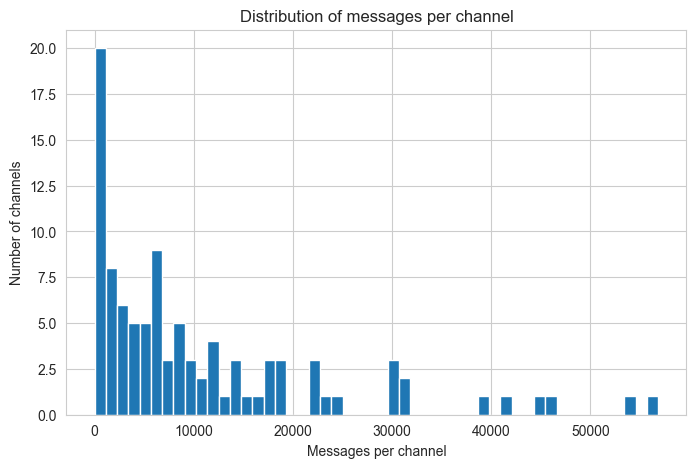

In [9]:
msgs_per_channel_number = messages_df.groupby('channel_id').size()

plt.figure(figsize=(8,5))
plt.hist(msgs_per_channel_number, bins=50)
plt.title("Distribution of messages per channel")
plt.xlabel("Messages per channel")
plt.ylabel("Number of channels")
plt.show()

_The right-skewed histogram shows that most channels publish a moderate number of messages while a handful of outliers produce far more, indicating an uneven distribution of activity across the network._

In [10]:
msgs_per_channel = messages_df.groupby('channel_id').size().reset_index(name='msg_count')
msgs_per_channel = msgs_per_channel.merge(
    channels_df[['channel_id', 'username', 'title']],
    on='channel_id',
    how='left'
)
top20 = msgs_per_channel.sort_values('msg_count', ascending=False).head(20)
top20

,channel_id,msg_count,username,title
11,1175084215,56849,ukr_2025_ru,Украина ру
5,1101170442,54130,rian_ru,РИА Новости
16,1194762769,45867,RBC_ua_news,РБК-Україна
41,1283178270,44934,uaobozrevatel,Obozrevatel.ua
31,1236359991,41325,novynylive,Новини.LIVE
3,1081358729,38736,nvua_official,NV | nv.ua | Радіо NV | Новини України | Аналі...
18,1197363285,31676,u_now,"Україна Сейчас | УС: новини, політика"
86,1746320324,31071,u_now_ua,"Україна на часі новини: війна, Росія"
28,1223955273,30470,kpszsu,Повітряні Сили ЗС України / Air Force of the A...
44,1305722586,30078,TCH_channel,TCH новини / TCH.ua


/var/folders/tl/165vkc4d64z11m4p76hwcldr0000gn/T/ipykernel_13257/1261785624.py:7: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tl/165vkc4d64z11m4p76hwcldr0000gn/T/ipykernel_13257/1261785624.py:7: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/Users/yuliavistak/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yuliavistak/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


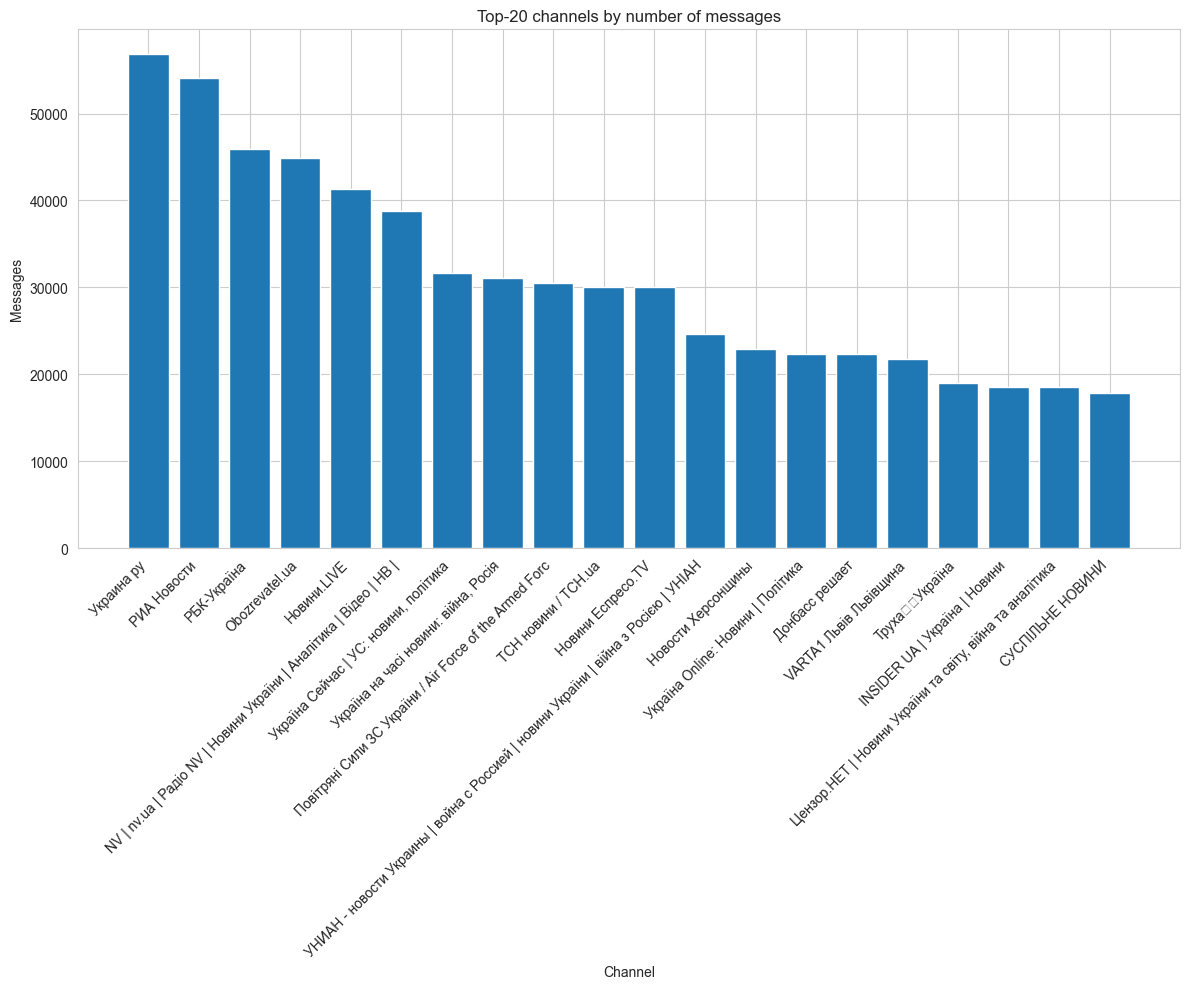

In [11]:
plt.figure(figsize=(12,10))
plt.bar(top20['title'], top20['msg_count'])
plt.xticks(rotation=45, ha='right')
plt.title("Top-20 channels by number of messages")
plt.xlabel("Channel")
plt.ylabel("Messages")
plt.tight_layout()
plt.show()

_A small number of channels account for a disproportionately large share of messages, suggesting a highly skewed publishing hierarchy among the monitored sources._

### Activity Depending on Time

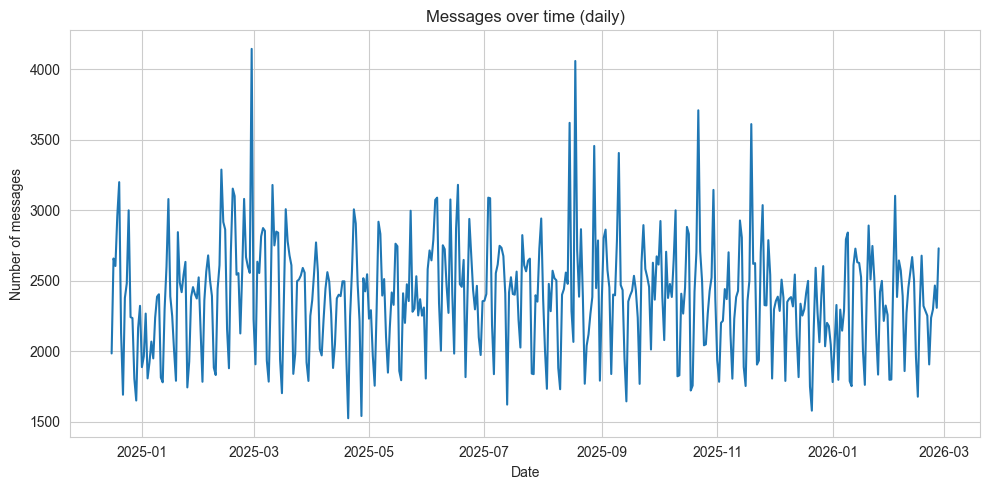

In [12]:
daily_counts = messages_df.set_index('date_utc').resample('D').size()

plt.figure(figsize=(10,5))
plt.plot(daily_counts[:-1]) # deleted the last day of the sample since the was too few messages
plt.title("Messages over time (daily)")
plt.xlabel("Date")
plt.ylabel("Number of messages")
plt.tight_layout()
plt.show()


_Daily message volume is broadly stable across the observation window with occasional short-lived spikes, confirming consistent channel activity rather than bursty or seasonal-only posting._

In [ ]:
# --- fix timezone ---
messages_df["date_utc"] = pd.to_datetime(messages_df["date_utc"]).dt.tz_localize(None)

# --- messages per week ---
weekly_counts = messages_df.set_index("date_utc").resample("W").size()[:-1]

# --- load events ---
events_path = project_root / 'config' / 'Important dates.csv'
events = pd.read_csv(events_path)
events["Date"] = pd.to_datetime(events["Date"])

# keep only events inside the plotted period
events = events[
    (events["Date"] >= weekly_counts.index.min()) &
    (events["Date"] <= weekly_counts.index.max())
]

# get y-values for event points
event_values = weekly_counts.reindex(events["Date"], method="nearest")  # pick closest week

# --- plot style ---
sns.set_theme(style="white")

plt.figure(figsize=(9,6))

# main line
plt.plot(weekly_counts.index, weekly_counts.values, linewidth=2.5)

# event points
plt.scatter(
    events["Date"],
    event_values,
    color="red",
    s=120,
    zorder=5
)

# titles and labels
plt.title("Weekly Message Activity", fontsize=22, pad=15)
plt.xlabel("Date", fontsize=18)
plt.ylabel("Messages per Week", fontsize=18)

ax = plt.gca()

# remove grid
ax.grid(False)

# keep only bottom axis line
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# --- Y axis formatting (like 1.5k, 2k, etc.) ---
ax.yaxis.set_major_locator(MultipleLocator(500))
def format_k(x, pos):
    val = x / 1000
    if val.is_integer():
        return f"{int(val)}k"
    # return f"{val:.1f}k"


ax.yaxis.set_major_formatter(FuncFormatter(format_k))

# --- date formatting ---
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# larger ticks
ax.tick_params(axis="both", labelsize=16)
# plt.xticks(rotation=30)


plt.tight_layout()
plt.show()

_Weekly posting volume fluctuates throughout the year, and the red markers align with key dates where activity noticeably surges or drops relative to the surrounding baseline._

In [14]:
daily_counts['2025-12-11'], daily_counts['2025-12-10']

(np.int64(2318), np.int64(2384))

### Top Channels' Activity

In [ ]:
# messages per channel (if not already computed)
msgs_per_channel = messages_df.groupby('channel_id').size()
top_channel_ids = msgs_per_channel.sort_values(ascending=False).head(5).index
tmp = messages_df[messages_df['channel_id'].isin(top_channel_ids)].copy()
tmp['day'] = tmp['date_utc'].dt.date
tmp.head()

,channel_id,message_id,channel_username,is_reply,reply_to_msg_id,is_forwarded,fwd_from_channel_id,fwd_from_message_id,date_utc,views,forwards,replies_count,has_media,text,day
19349,1101170442,328038,rian_ru,False,NaN,False,NaN,NaN,2025-11-30 23:27:10,550083.0,510.0,NaN,False,эксперты рассказали как выгодно продлить новог...,2025-11-30
19350,1101170442,328037,rian_ru,False,NaN,False,NaN,NaN,2025-11-30 22:58:19,554189.0,207.0,NaN,False,погода на следующей неделе в москве будет одно...,2025-11-30
19351,1101170442,328036,rian_ru,False,NaN,False,NaN,NaN,2025-11-30 22:23:02,578827.0,447.0,NaN,False,трамп не намерен устанавливать для россии дедл...,2025-11-30
19352,1101170442,328035,rian_ru,True,NaN,False,NaN,NaN,2025-11-30 22:19:05,558300.0,379.0,NaN,False,сша и киев на переговорах во флориде обсуждали...,2025-11-30
19353,1101170442,328034,rian_ru,False,NaN,False,NaN,NaN,2025-11-30 21:53:51,599166.0,524.0,NaN,False,у украины есть небольшие проблемы в переговора...,2025-11-30


In [ ]:
pivot = (
    tmp
    .groupby(['day', 'channel_username'])
    .size()
    .unstack(fill_value=0)
)

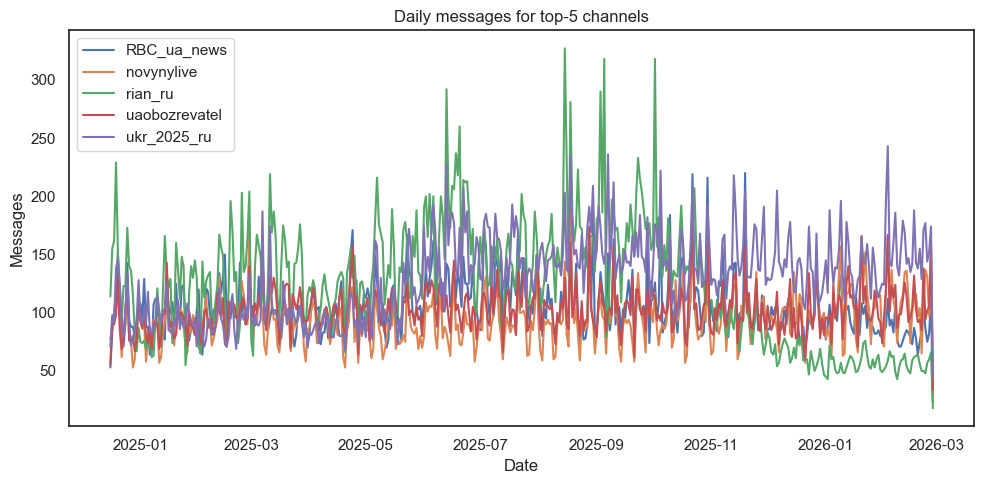

In [ ]:
plt.figure(figsize=(10,5))

for ch in pivot.columns:
    plt.plot(pivot.index, pivot[ch], label=ch)

plt.title("Daily messages for top-5 channels")
plt.xlabel("Date")
plt.ylabel("Messages")
plt.legend()
plt.tight_layout()
plt.show()


_The five most active channels follow distinct posting cadences — some publish in dense bursts while others maintain a steady daily volume — which may reflect differences in editorial strategy or coordination patterns._

# Step 3: Make Samples for Labeling

## Strong Labeling

Four non-overlapping stratified samples of 100 messages each are drawn proportionally by ISO week to ensure temporal coverage: a pilot batch for calibration, followed by three batches assigned to individual annotators.

In [9]:
# Pilot sample (calibration / quality check)
remaining_pool = stratified_sample_by_week(messages_df, 'labeling.csv', 100)
# Annotator 1
remaining_pool = stratified_sample_by_week(remaining_pool, 'labeling_annotator_1.csv', 100)
# Annotator 2
remaining_pool = stratified_sample_by_week(remaining_pool, 'labeling_annotator_2.csv', 100)
# Annotator 3
remaining_pool = stratified_sample_by_week(remaining_pool, 'labeling_annotator_3.csv', 100)

In [22]:
len(messages_df), len(remaining_pool)

(1047570, 1047114)

## Weak Labeling

Weak labels are derived automatically from three complementary signals — explicit forwarding chains, high-confidence semantic similarity, and pre-computed message embeddings — to scale annotation beyond what manual review can cover.

### Explicit Forwardings

Collects messages that were forwarded between channels within the dataset and retrieves both the forwarded copy and the original source message to form labeled pairs.

In [10]:
messages_forwarded_to = remaining_pool[
    remaining_pool['fwd_from_channel_id'].isin(channels_df['channel_id'])
]
# messages_forwarded_to.to_csv("messages_forwarded_to.csv", index=False)

In [11]:
pairs = (
    messages_forwarded_to[['fwd_from_channel_id', 'fwd_from_message_id']]
    .dropna()
    .drop_duplicates()
)
pairs = pairs.rename(columns={
    'fwd_from_channel_id': 'channel_id',
    'fwd_from_message_id': 'message_id'
})

In [12]:
missing_pairs = pairs.merge(
    messages_forwarded_to[['channel_id', 'message_id']].drop_duplicates(),
    on=['channel_id', 'message_id'],
    how='left',
    indicator=True
)

missing_pairs = missing_pairs[missing_pairs['_merge'] == 'left_only']
missing_pairs = missing_pairs[['channel_id', 'message_id']]

messages_forwarded_from = remaining_pool.merge(
    missing_pairs,
    on=['channel_id', 'message_id'],
    how='inner'
)
# messages_forwarded_from.to_csv("messages_forwarded_from.csv", index=False)

In [13]:
len(messages_forwarded_to), len(messages_forwarded_from)

(36208, 34604)

In [28]:
messages_forwards = pd.concat([messages_forwarded_from, messages_forwarded_to], ignore_index=True)
# messages_forwards.to_csv("messages_forwards.csv", index=False)

### Semantic Similarity

Loads pre-computed pairwise similarity scores and retains only pairs above a 0.985 threshold, then enriches each pair with the full message text from both sides.

In [ ]:
semantic_similarity_pairs = pd.read_csv(project_root / 'data' / 'semantic_similarity_pairs.csv')
semantic_similarity_pairs = semantic_similarity_pairs[semantic_similarity_pairs['similarity_score'] >= 0.985]
# len(semantic_similarity_pairs)

In [47]:
src_matched = semantic_similarity_pairs.merge(
    messages_df[['channel_id', 'message_id', 'channel_username', 'text']],
    left_on=['src_channel_id', 'src_message_id'],
    right_on=['channel_id', 'message_id'],
    how='inner'
)
src_matched = src_matched.rename(columns={
    'channel_username': 'src_channel_username',
    'text': 'src_text'
})

src_matched = src_matched.drop(columns=['channel_id', 'message_id'])

In [49]:
dst_matched = src_matched.merge(
    messages_df[['channel_id', 'message_id', 'channel_username', 'text']],
    left_on=['dst_channel_id', 'dst_message_id'],
    right_on=['channel_id', 'message_id'],
    how='inner'
)
dst_matched = dst_matched.rename(columns={
    'channel_username': 'dst_channel_username',
    'text': 'dst_text'
})

dst_matched = dst_matched.drop(columns=['channel_id', 'message_id'])

### Embeddings

Joins pre-computed message embeddings to both the forwarding pairs and the semantic similarity pairs so that downstream models have vector representations for each message in a labeled pair.

In [52]:
message_embeddings = pd.read_parquet(project_root / 'data' / 'message_embeddings.parquet')

In [ ]:
messages_forwards = messages_forwards.merge(message_embeddings, on=['channel_id', 'message_id'], how='inner')
messages_forwards = messages_forwards.drop(columns=['clean_len', 'embedding_model', 'embedding_dim', 'embedding_batch'])
# messages_forwards.to_parquet("messages_forwards.parquet")
# messages_forwards.head()

In [ ]:
src_matched = dst_matched.merge(
    message_embeddings,
    left_on=['src_channel_id', 'src_message_id'],
    right_on=['channel_id', 'message_id'],
    how='inner'
)
src_matched = src_matched.rename(columns={
    'embedding': 'src_embedding'
})
src_matched = src_matched.drop(columns=['channel_id', 'message_id', 'clean_len', 'embedding_model', 'embedding_dim', 'embedding_batch'])
# src_matched.head()

In [ ]:
dst_matched = src_matched.merge(
    message_embeddings,
    left_on=['dst_channel_id', 'dst_message_id'],
    right_on=['channel_id', 'message_id'],
    how='inner'
)

dst_matched = dst_matched.rename(columns={
    'embedding': 'dst_embedding'
})
dst_matched = dst_matched.drop(columns=['channel_id', 'message_id', 'clean_len', 'embedding_model', 'embedding_dim', 'embedding_batch'])
# dst_matched.to_parquet("semantic_similarity_pairs.parquet")
# dst_matched.head()